## CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026

# Weekly Homework 12: Probabilistic Data Structures

***Goals of this homework:***
- Implement a Bloom filter from scratch and understand its false positive behavior.
- Derive and apply the optimal Bloom filter parameters for a target error rate.
- Reason about the tradeoffs between space efficiency, accuracy, and computational cost in probabilistic data structures.

***Submission instructions:***

You should post your notebook to Canvas (look for the assignment there). Please name your submission **your-uin_hw12.ipynb**. Your notebook should be fully executed when you submit ... so run all the cells for us so we can see the output, then submit that.

***Grading philosophy:***

We are grading reasoning, judgment, and clarity, not just correctness. Show us that you understand the data, the constraints, and the limits of your conclusions.

***For each question, you need to respond with 2 cells:***
1. **[A Code Cell] Your Code:**
  - If code is not applicable for the question, you can skip this cell.
  - For tests: tests can be simple assertions or checks (e.g., using `assert` or `print` or small functions or visual inspection); formal testing frameworks are not required.
  - Include **2–3 assertions or print-based checks** that verify your implementation is correct. Choose tests that would catch the most common bugs.
2. **[A Markdown Cell] Your Answer:** Write up your answers and explain them in complete sentences. Explain what tests you wrote and **why those specific tests prove your code is correct** (not just that it ran). Include any videos in this section as well; for videos, upload them to your TAMU Google Drive, and ensure they are set to be visible by the instruction team (set to: **anyone with a TAMU email can view**), then share the link to the video in the cell.

***At the end of each Section (A/B/C/...) include a cell for your resources:***

**[A Markdown Cell] Your Resources:** You need to cite 3 types of resources and note how they helped you: (1) Collaborators, (2) Web Sources (e.g. StackOverflow), and (3) AI Tools (you must also describe how you prompted, but we do not require any links to any specific chats). Specifically, use the following format as a template:
```
On my honor, I declare the following resources:
1. Collaborators:
- Reveille A.: Helped me understand that a df in pandas is a data structure kinda like a CSV.
- Sully A.: Helped me fix a bug with the vector addition of 2 columns.
- ...

2. Web Sources:
- https://stackoverflow.com/questions/46562479/python-pandas-data-frame-creation: how to create a pd df
- ...

3. AI Tools:
- ChatGPT: I gave it the homework .ipynb file and the ufo.csv, and told it to generate the code for the first question, but it did it with csv.reader(), so I re-prompted it to use pandas and that one was correct
- ...
```

***Why do we require this cell?*** This cell is important...

1. For academic integrity, you must give credit where credit is due.

2. We want you to pay attention to how you can successfully get help to move through problems! Is there someone you work with or an AI tool that helps you learn the material better? That's great! The point of engineering is to use your tools to solve hard problems, and part of graduate school is learning about how *you* learn and solve problems best.

***A reminder: you get out of it what you put into it.***
Do your best on these homeworks, show us your creativity, and ask for help when you need it -- good luck!

---
## Preliminaries: Setup

Run the cells below once before starting. They install dependencies and load the dataset. You do not need to modify these cells.

**Dataset:** 200K Short Texts for Humor Detection. Each row is a short text with a humor/not-humor label. For this assignment, imagine these texts are arriving as a live stream of user-submitted jokes to your humor classification API. The first 70% of texts have already been processed by your classifier; the remaining 30% are new submissions arriving now.

The `humor.csv` file is provided on Canvas alongside this notebook.

In [1]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install pandas matplotlib -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import hashlib, math, struct
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# ── Load Humor dataset ────────────────────────────────────────────────────────
import pandas as pd

humor = pd.read_csv('humor.csv')
print(f'Rows: {len(humor):,}')
print(f'Columns: {list(humor.columns)}')
humor.head()

Rows: 200,000
Columns: ['text', 'humor']


,text,humor
0,"Joe biden rules out 2020 bid: 'guys, i'm not r...",False
1,Watch: darvish gave hitter whiplash with slow ...,False
2,What do you call a turtle without its shell? d...,True
3,5 reasons the 2016 election feels so personal,False
4,"Pasco police shot mexican migrant from behind,...",False


---
# A [63pts].

**Rubric**

[16 pts] Strong/Professional: Correct and complete implementation; reasonable and stated assumptions; thoughtful handling of real-world data (missingness, noise, scale, edge cases); tests are meaningful and the written explanation convincingly argues why they prove correctness; clear, concise prose; code is clean and readable; interpretation goes beyond restating output.

[9 pts] Partial/Developing: Core task mostly complete but with gaps or minor mistakes; tests are present but superficial or poorly justified; reasoning is shallow or mostly descriptive.

[0 pts] Minimal/Incorrect: Task largely incorrect or missing; no meaningful tests; code does not run.

You've built a humor classifier and deployed it as a live API — users submit jokes and your model scores them. The service is popular: **millions of submissions per day**, and it turns out people resubmit the same jokes constantly. Every duplicate that hits your classifier wastes GPU time and money. You need a **deduplication layer** in front of the model.

A naive approach — store every text you've ever seen in a set and check membership — works at small scale but blows up in memory as the stream grows. **Bloom filters** solve this: a compact, probabilistic data structure that can tell you 'definitely haven't seen this' or 'probably seen this' using a fraction of the memory. The tradeoff is false positives: occasionally a *new* joke gets flagged as a duplicate and skipped. How often that happens — and what it costs — depends entirely on how you configure the filter.

In this section, you'll build the deduplication layer from scratch, tune it for a target error rate, and reason about what your parameter choices mean for real users who submitted a genuinely new joke that your filter incorrectly ate.

# 1. Bloom Filter: Predict, Then Verify  [16pts]

Implement a Bloom filter from scratch for the humor text stream. Insert the **first 70%** of texts into the filter. Hold out the remaining **30%** — do not insert them. You need this split for the same reason you need a test set in ML: to measure the false positive rate, you need strings that are *definitely not* in the filter. If you inserted everything, every query would be a true member and you'd have no way to observe false positives.

First, run your 70/30 split to determine **m** (the number of elements in the 70% stream) — you will need this value for the formula. Then compute the theoretical FPR by hand for these three configurations (show your work using the formula FPR ≈ (1 − e^(−km/n))^k, where **m** is the number of elements inserted (darts) and **n** is the number of bits in the filter (targets)):

| Config | n (bits) | k (hashes) | Your predicted FPR |
|--------|----------|------------|--------------------|
| A      | 1,000,000 | 5        | ?                  |
| B      | 500,000   | 3        | ?                  |
| C      | 2,000,000 | 10       | ?                  |

Now implement and run all three. Check membership of the held-out **30%** (do not insert them) and measure the **empirical FPR**.

> **Hint:** Some holdout texts may also appear in the 70% stream (duplicates in the dataset). A holdout item that's *actually* in the filter is a true positive, not a false positive. To measure FPR correctly, you should only count false positives among holdout items that are *genuinely absent* from the stream. Think about how to filter those out before computing FPR.

1. Fill in a table comparing your predicted FPR vs. empirical FPR for each configuration.
3. Plot predicted vs. empirical FPR for all three configs.

**Testing:** Include 2–3 assertions or print-based checks directly in your code cell. In your written answer, explain what tests you wrote and **why those specific tests prove your code is correct**.

cfg 1 expected fpr: 0.03233176763296942
cfg 1 empirical fpr: 0.031166666666666665
cfg 2 expected fpr: 0.18353075108145842
cfg 2 empirical fpr: 0.18205
cfg 3 expected fpr: 0.0010453431982723287
cfg 3 empirical fpr: 0.001


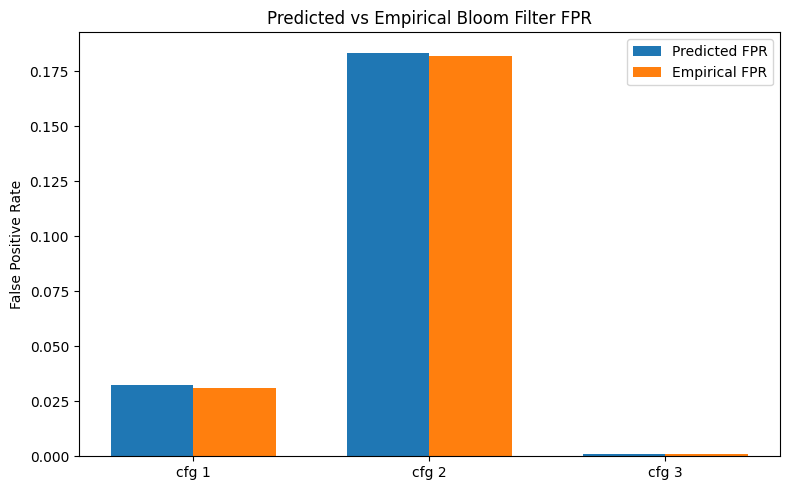

In [10]:
from sklearn.model_selection import train_test_split
import hashlib
import math
import matplotlib.pyplot as plt

train_df, test_df = train_test_split(humor, test_size=0.3, random_state=42)

class BloomFilter:
    def __init__(self, k, n):
        self.k = k
        self.n = n
        self.bit_arr = bytearray(n)

    def add(self, item):
        if isinstance(item, str):
            item = item.encode()
        h = hashlib.sha256(item).digest()
        first_half = int.from_bytes(h[:16], "big")
        last_half = int.from_bytes(h[16:], "big")
        for i in range(self.k):
            index = (first_half + i * last_half) % self.n
            self.bit_arr[index] = 1

    def add_dataframe(self, df):
        for text in df["text"]:
            self.add(text)

    def test(self, item):
        if isinstance(item, str):
            item = item.encode()
        h = hashlib.sha256(item).digest()
        first_half = int.from_bytes(h[:16], "big")
        last_half = int.from_bytes(h[16:], "big")
        for i in range(self.k):
            index = (first_half + i * last_half) % self.n
            if self.bit_arr[index] == 0:
                return False
        return True

def calc_expected_fpr(m, n, k):
    return (1 - math.exp(-k * m / n)) ** k

def calc_actual_fpr(bloom_filter, test_df, training_texts):
    false_positive = 0
    total = 0
    for text in test_df["text"]:
        if text in training_texts:
            continue
        if bloom_filter.test(text):
            false_positive += 1
        total += 1
    return false_positive / total

training_texts = set(train_df["text"].unique())
m = len(train_df)

configs = [
    (5, 1_000_000),
    (3, 500_000),
    (10, 2_000_000),
]

labels = []
expected_fprs = []
empirical_fprs = []

for idx, (k, n) in enumerate(configs, start=1):
    bf = BloomFilter(k=k, n=n)
    bf.add_dataframe(train_df)
    
    expected_fpr = calc_expected_fpr(m, n, k)
    empirical_fpr = calc_actual_fpr(bf, test_df, training_texts)
    
    labels.append(f"cfg {idx}")
    expected_fprs.append(expected_fpr)
    empirical_fprs.append(empirical_fpr)
    
    print(f"cfg {idx} expected fpr: {expected_fpr}")
    print(f"cfg {idx} empirical fpr: {empirical_fpr}")

# plot
x = range(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], expected_fprs, width=width, label="Predicted FPR")
plt.bar([i + width/2 for i in x], empirical_fprs, width=width, label="Empirical FPR")

plt.xticks(list(x), labels)
plt.ylabel("False Positive Rate")
plt.title("Predicted vs Empirical Bloom Filter FPR")
plt.legend()
plt.tight_layout()
plt.show()

| Config | k  | n        | Expected FPR        | Empirical FPR |
|--------|----|----------|---------------------|---------------|
| 1      | 5  | 1,000,000| 0.03233176763296942 | 0.031166666666666665 |
| 2      | 3  | 500,000  | 0.18353075108145842 | 0.18205       |
| 3      | 10 | 2,000,000| 0.00104534319827233 | 0.001         |  



# 2. Most Efficient Bloom Filter  [16pts]

- It turns out you can optimize m and k for a given n (the number of elements to store) and p (the false positive probability) to yield a space-efficient Bloom filter. You may need to do a little research to dig into what this optimization is.
- For this part, consider p ∈ {0.5%, 1%, 2%, 5%} and the same 70% of the data as your n. What are the space-efficient m and k for these settings?
- Discuss your findings and how to interpret them.

**Testing:** Include 2–3 assertions or print-based checks directly in your code cell. In your written answer, explain what tests you wrote and **why those specific tests prove your code is correct**.

*your answer here*

# 3. Design Decision: Content Moderation Pipeline  [16pts]

You're building a **content moderation pipeline** that processes **10 million posts per day**. You have **50 MB of memory** for the duplicate-detection filter. Every false positive means a human reviewer has to manually check the flagged post (costing ~$0.10 per review).

1. **Design the filter.** Choose n (bits) and k (hashes) for this scenario. Show your reasoning — how many bits do you have, what FPR does that give you, and how many false positives per day does that translate to?
2. **Cost analysis.** Compute the daily cost of false positives at FPR = 5% vs. FPR = 0.5%. Write a short paragraph describing what happens to real users and real reviewers under each scenario. Which would you recommend to your manager, and why?
3. **A teammate suggests** using the Bloom filter to *count* how many times each post appeared (not just whether it appeared). Explain why this doesn't work. What data structure would you need instead? (Hint: look up **counting Bloom filters**.)
4. **Another teammate asks:** *'Why not just use a database?'* Give a one-sentence answer for when that's the right call and when it isn't.

**Testing:** Include 2–3 assertions or print-based checks directly in your code cell. In your written answer, explain what tests you wrote and **why those specific tests prove your code is correct**.

*your answer here*

# 4. Bloom Filter vs. Python Set: Empirical Memory Comparison  [15pts]

Your teammate looks at your Bloom filter and says: *"Why not just use a Python set? It's exact — no false positives, no tuning. What are we actually saving?"*

Find out empirically.

1. Insert the first 70% of humor texts into both a **Python `set`** and your **optimal Bloom filter** from Q2 (pick the p=1% configuration). Use `sys.getsizeof` for the set and compute the Bloom filter's memory as `n / 8` bytes. Report both in MB.
2. **Scale it up.** Repeat the measurement for increasing fractions of the data: 10%, 20%, 30%, ..., 100% of the texts. Plot **memory usage (MB) vs. number of elements** for both the set and the Bloom filter on the same axes.
3. At what dataset size does the Bloom filter become clearly cheaper? How does the set's memory grow compared to the Bloom filter's? (Hint: one is O(n) in the size of the *data*, the other is O(n) in the *count* — what's the difference?)
4. **The catch.** `sys.getsizeof` on a set only measures the hash table, not the strings it points to. Use `sum(sys.getsizeof(s) for s in your_set) + sys.getsizeof(your_set)` to get the *true* memory cost including the string objects. Re-plot with this corrected measurement. How much does the gap widen?
5. **One paragraph:** Given your measurements, at what scale (number of elements, average string length) does the Bloom filter's space advantage justify its false positive cost? Would your answer change if the strings were URLs (avg ~80 chars) vs. tweets (avg ~140 chars) vs. full documents (avg ~5000 chars)?

**Testing:** Include 2–3 assertions or print-based checks directly in your code cell. In your written answer, explain what tests you wrote and **why those specific tests prove your code is correct**.

*your answer here*

# Resources for Section A

```
On my honor, I declare the following resources:
1. Collaborators:
- ...

2. Web Sources:
- ...

3. AI Tools:
- ...
```

---
# B [28pts]. Interview Questions

We now pretend this is a real job interview. Here's some guidance on how to answer these questions:

1. Briefly restate the question and state any assumptions you are making.
2. Explain your reasoning out loud, focusing on tradeoffs, limitations, and constraints.
3. Keep answers as short and clear as they can be (while still answering the question).
4. Write/speak in a conversational but professional tone.

There may not be a single correct answer. We are grading whether your reasoning is reasonable and aware of limitations.

**Rubric**

[7pt] Clear understanding of the question; reasonable assumptions; thoughtful reasoning that acknowledges tradeoffs and limitations; clear, concise communication.

[4pt] Basic understanding but shallow reasoning or unclear assumptions.

[0pt] Minimal, unclear, or incorrect response.

# 1.
Your Bloom filter has a 2% false positive rate. A product manager asks: is that good enough? How do you answer that question?

*your answer here*

# 2.
You measured that a Python set uses 10× more memory than your Bloom filter for the same data. Your teammate says the set is still better because it has no false positives. Who's right?

*your answer here*

# 3.
(Video) Walk me through what happened when you compared your predicted FPR to your empirical FPR. Did they match? If not, what does that tell you about the assumptions behind the theory?

*your answer here (include video link)*

# 4.
Two near-duplicate tweets arrive in your stream — same joke, slightly reworded. The Bloom filter says it hasn't seen the second one. Is that a problem? What would you need to catch semantic duplicates instead?

*your answer here*

# Resources for Section B

```
On my honor, I declare the following resources:
1. Collaborators:
- ...

2. Web Sources:
- ...

3. AI Tools:
- ...
```

---
# C [9pts]. What new questions do you have?
We want you to think bigger! Tell us what questions and curiosity this homework brings up for you.

**Rubric**

[9pt] Complete, thoughtful response.

[5pt] Partial response.

[0pt] Minimal response.

# 1.
What new questions do you have after this homework? Or, what topics are you curious about now? List at least 3.

*your answer here*